### Introduction to Text Analysis using Python Libraries

* Tokenisation
* Lemmatization

In [1]:
# import libraries

from textblob import TextBlob

In [2]:
text = "Hi, I am a good man manager"

In [3]:
#Initialise textblob
blob = TextBlob(text)

In [4]:
# Tokenise text
tokens = blob.tokenize()
tokens

WordList(['Hi', ',', 'I', 'am', 'a', 'good', 'man', 'manager'])

In [5]:
#Creating a list of stop words 
stop_words = [',', 'I', 'am', 'a']

In [6]:
# List of cleaned words
clean_tokens = [w for w in tokens if w not in stop_words] #iterates over tokens, and returns words that are not in stop_words list.
clean_tokens

['Hi', 'good', 'man', 'manager']

In [7]:
# Join the clean tokens

cleaned_text = " ".join(clean_tokens)
cleaned_text

'Hi good man manager'

In [8]:
#Create a new text blob
clean_blob = TextBlob(cleaned_text)
clean_blob

TextBlob("Hi good man manager")

In [9]:
clean_blob.tags

[('Hi', 'NNP'), ('good', 'JJ'), ('man', 'NN'), ('manager', 'NN')]

### Lemmatization

In [10]:
from textblob import Word

In [11]:
w = Word('running')
w

'running'

In [12]:
w.lemmatize('v')

'run'

### Clean Text and Word Frequency Using NLTK

In [13]:
import nltk
nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

In [14]:
#Import libraries
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import ngrams
import seaborn as sns
import matplotlib.pyplot as plt



In [15]:
#Load Data set
df = pd.read_csv('../data/reddit_wsb.csv')

In [16]:
df.head(5)

,title,score,id,url,comms_num,created,body,timestamp
0,"It's not about the money, it's about sending a...",55,l6ulcx,https://v.redd.it/6j75regs72e61,6,1.611863e+09,NaN,2021-01-28 21:37:41
1,Math Professor Scott Steiner says the numbers ...,110,l6uibd,https://v.redd.it/ah50lyny62e61,23,1.611862e+09,NaN,2021-01-28 21:32:10
2,Exit the system,0,l6uhhn,https://www.reddit.com/r/wallstreetbets/commen...,47,1.611862e+09,The CEO of NASDAQ pushed to halt trading “to g...,2021-01-28 21:30:35
3,NEW SEC FILING FOR GME! CAN SOMEONE LESS RETAR...,29,l6ugk6,https://sec.report/Document/0001193125-21-019848/,74,1.611862e+09,NaN,2021-01-28 21:28:57
4,"Not to distract from GME, just thought our AMC...",71,l6ufgy,https://i.redd.it/4h2sukb662e61.jpg,156,1.611862e+09,NaN,2021-01-28 21:26:56


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53187 entries, 0 to 53186
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      53187 non-null  str    
 1   score      53187 non-null  int64  
 2   id         53187 non-null  str    
 3   url        53187 non-null  str    
 4   comms_num  53187 non-null  int64  
 5   created    53187 non-null  float64
 6   body       24738 non-null  str    
 7   timestamp  53187 non-null  str    
dtypes: float64(1), int64(2), str(5)
memory usage: 3.2 MB


In [18]:
#Extract date component from timestamp column
df['Date'] = pd.to_datetime(df['timestamp']).dt.date

In [19]:
df.head(5)

,title,score,id,url,comms_num,created,body,timestamp,Date
0,"It's not about the money, it's about sending a...",55,l6ulcx,https://v.redd.it/6j75regs72e61,6,1.611863e+09,NaN,2021-01-28 21:37:41,2021-01-28
1,Math Professor Scott Steiner says the numbers ...,110,l6uibd,https://v.redd.it/ah50lyny62e61,23,1.611862e+09,NaN,2021-01-28 21:32:10,2021-01-28
2,Exit the system,0,l6uhhn,https://www.reddit.com/r/wallstreetbets/commen...,47,1.611862e+09,The CEO of NASDAQ pushed to halt trading “to g...,2021-01-28 21:30:35,2021-01-28
3,NEW SEC FILING FOR GME! CAN SOMEONE LESS RETAR...,29,l6ugk6,https://sec.report/Document/0001193125-21-019848/,74,1.611862e+09,NaN,2021-01-28 21:28:57,2021-01-28
4,"Not to distract from GME, just thought our AMC...",71,l6ufgy,https://i.redd.it/4h2sukb662e61.jpg,156,1.611862e+09,NaN,2021-01-28 21:26:56,2021-01-28


In [20]:
#Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [21]:
#Extract Month-Year String
df['Month-Year'] = df['Date'].dt.strftime('%y-%m')
df.head(5)

,title,score,id,url,comms_num,created,body,timestamp,Date,Month-Year
0,"It's not about the money, it's about sending a...",55,l6ulcx,https://v.redd.it/6j75regs72e61,6,1.611863e+09,NaN,2021-01-28 21:37:41,2021-01-28,21-01
1,Math Professor Scott Steiner says the numbers ...,110,l6uibd,https://v.redd.it/ah50lyny62e61,23,1.611862e+09,NaN,2021-01-28 21:32:10,2021-01-28,21-01
2,Exit the system,0,l6uhhn,https://www.reddit.com/r/wallstreetbets/commen...,47,1.611862e+09,The CEO of NASDAQ pushed to halt trading “to g...,2021-01-28 21:30:35,2021-01-28,21-01
3,NEW SEC FILING FOR GME! CAN SOMEONE LESS RETAR...,29,l6ugk6,https://sec.report/Document/0001193125-21-019848/,74,1.611862e+09,NaN,2021-01-28 21:28:57,2021-01-28,21-01
4,"Not to distract from GME, just thought our AMC...",71,l6ufgy,https://i.redd.it/4h2sukb662e61.jpg,156,1.611862e+09,NaN,2021-01-28 21:26:56,2021-01-28,21-01


## Exploratory Data Analysis

In [22]:
df.groupby(['Month-Year'])['title'].count()

Month-Year
20-09        1
21-01    19254
21-02    17438
21-03     7283
21-04     1991
21-05     2259
21-06     2750
21-07     1360
21-08      851
Name: title, dtype: int64

In [23]:
# for comments made after dec 2020

mask = (df['Date'] >= '01/01/2021') & (df['Date'] <= '31/03/2021')
df_jan_mar = df[mask]

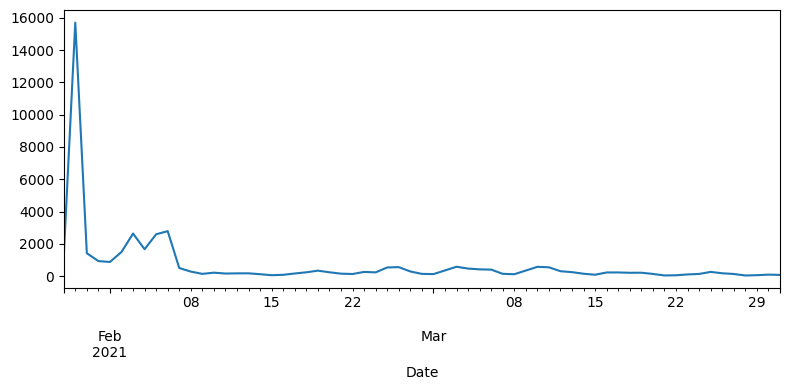

In [24]:
#Visualise time series
df_jan_mar.groupby(['Date'])['title'].count().plot(figsize=(8,4))
plt.tight_layout()

## Text Analysis

In [25]:
#Create bag of words
comments = " ".join(df_jan_mar['title'])
comments

'It\'s not about the money, it\'s about sending a message. 🚀💎🙌 Math Professor Scott Steiner says the numbers spell DISASTER for Gamestop shorts Exit the system NEW SEC FILING FOR GME! CAN SOMEONE LESS RETARDED THAN ME PLEASE INTERPRET? Not to distract from GME, just thought our AMC brothers should be aware of this WE BREAKING THROUGH SHORT STOCK DOESN\'T HAVE AN EXPIRATION DATE THIS IS THE MOMENT Currently Holding AMC and NOK - Is it retarded that I think I should move it all to GME today? I have nothing to say but BRUH I am speechless TO THE MOON 🚀🚀🚀💎💎👋👋 We need to keep this movement going, we all can make history! GME Premarket 🍁 Musk approved 🎮🛑💎✋ Once you\'re done with GME - $AG and $SLV, the gentleman\'s short squeeze, driven by macro fundamentals $GME price has nothing to do with fundamentals and everything to do with financial economics I Love You Retards!!!! 420 wasn’t a meme. GME 🚀 🚀 🚀 To The Mass Relays & Beyond I come back to you now... At the turn of the tide. 9 words broug

In [26]:
#Tokenize the comments
tokens = word_tokenize(comments)
tokens

['It',
 "'s",
 'not',
 'about',
 'the',
 'money',
 ',',
 'it',
 "'s",
 'about',
 'sending',
 'a',
 'message',
 '.',
 '🚀💎🙌',
 'Math',
 'Professor',
 'Scott',
 'Steiner',
 'says',
 'the',
 'numbers',
 'spell',
 'DISASTER',
 'for',
 'Gamestop',
 'shorts',
 'Exit',
 'the',
 'system',
 'NEW',
 'SEC',
 'FILING',
 'FOR',
 'GME',
 '!',
 'CAN',
 'SOMEONE',
 'LESS',
 'RETARDED',
 'THAN',
 'ME',
 'PLEASE',
 'INTERPRET',
 '?',
 'Not',
 'to',
 'distract',
 'from',
 'GME',
 ',',
 'just',
 'thought',
 'our',
 'AMC',
 'brothers',
 'should',
 'be',
 'aware',
 'of',
 'this',
 'WE',
 'BREAKING',
 'THROUGH',
 'SHORT',
 'STOCK',
 'DOES',
 "N'T",
 'HAVE',
 'AN',
 'EXPIRATION',
 'DATE',
 'THIS',
 'IS',
 'THE',
 'MOMENT',
 'Currently',
 'Holding',
 'AMC',
 'and',
 'NOK',
 '-',
 'Is',
 'it',
 'retarded',
 'that',
 'I',
 'think',
 'I',
 'should',
 'move',
 'it',
 'all',
 'to',
 'GME',
 'today',
 '?',
 'I',
 'have',
 'nothing',
 'to',
 'say',
 'but',
 'BRUH',
 'I',
 'am',
 'speechless',
 'TO',
 'THE',
 'MOON',
 

In [27]:
from better_profanity import profanity

In [28]:
stop_words2 = set(stopwords.words('english'))  # load once do not include inside the function

In [29]:
# Text cleaning function to remove stopwords, punctuations, and lemmatize

def clean_title(cleaned_titles):
    cleaned_titles = [r.lower() for r in cleaned_titles]
    cleaned_titles = [r for r in cleaned_titles if r not in stop_words2]
    cleaned_titles = [r for r in cleaned_titles if r.isalpha()]
    cleaned_titles = [r for r in cleaned_titles if not profanity.contains_profanity(r)]
    lemmatizer = WordNetLemmatizer()
    cleaned_titles = [lemmatizer.lemmatize(r) for r in cleaned_titles]
    return cleaned_titles




In [30]:
cleaned_tokens = clean_title(tokens)

In [31]:
cleaned_tokens

['money',
 'sending',
 'message',
 'math',
 'professor',
 'scott',
 'steiner',
 'say',
 'number',
 'spell',
 'disaster',
 'gamestop',
 'short',
 'exit',
 'system',
 'new',
 'sec',
 'filing',
 'gme',
 'someone',
 'less',
 'please',
 'interpret',
 'distract',
 'gme',
 'thought',
 'amc',
 'brother',
 'aware',
 'breaking',
 'short',
 'stock',
 'expiration',
 'date',
 'moment',
 'currently',
 'holding',
 'amc',
 'nok',
 'think',
 'move',
 'gme',
 'today',
 'nothing',
 'say',
 'bruh',
 'speechless',
 'moon',
 'need',
 'keep',
 'movement',
 'going',
 'make',
 'history',
 'gme',
 'premarket',
 'musk',
 'approved',
 'done',
 'gme',
 'ag',
 'slv',
 'gentleman',
 'short',
 'squeeze',
 'driven',
 'macro',
 'fundamental',
 'gme',
 'price',
 'nothing',
 'fundamental',
 'everything',
 'financial',
 'economics',
 'love',
 'retard',
 'meme',
 'gme',
 'mass',
 'relay',
 'beyond',
 'come',
 'back',
 'turn',
 'tide',
 'word',
 'brought',
 'sec',
 'daily',
 'discussion',
 'thread',
 'january',
 'gme',
 're

In [32]:
from collections import Counter

In [33]:
word_count = Counter(cleaned_tokens)
word_count

Counter({'gme': 8359,
         'buy': 3890,
         'hold': 3232,
         'robinhood': 3167,
         'amc': 3122,
         'stock': 2603,
         'holding': 1985,
         'share': 1885,
         'still': 1812,
         'like': 1622,
         'short': 1615,
         'let': 1612,
         'sell': 1560,
         'moon': 1539,
         'go': 1343,
         'get': 1338,
         'u': 1289,
         'bought': 1277,
         'today': 1241,
         'going': 1219,
         'bb': 1193,
         'market': 1184,
         'dip': 1167,
         'yolo': 1107,
         'nok': 1059,
         'time': 1041,
         'loss': 1030,
         'ape': 1003,
         'trading': 968,
         'buying': 965,
         'back': 964,
         'wsb': 959,
         'selling': 940,
         'money': 911,
         'one': 883,
         'day': 871,
         'guy': 843,
         'hand': 821,
         'squeeze': 802,
         'gamestop': 798,
         'right': 772,
         'fund': 769,
         'new': 757,
         'w

In [34]:
count = Counter(ngrams(cleaned_tokens,3))
pd.DataFrame(count.items(), columns=['ngram', 'count'])

,ngram,count
0,"(money, sending, message)",3
1,"(sending, message, math)",1
2,"(message, math, professor)",1
3,"(math, professor, scott)",1
4,"(professor, scott, steiner)",1
...,...,...
235963,"(market, open, chewy)",1
235964,"(open, chewy, chwy)",1
235965,"(chewy, chwy, exceeds)",1
235966,"(chwy, exceeds, fiscal)",1


## Super Function


In [42]:
# Create data cleaning function to remove stopwords, punctuation, and lemmatize.

stop_words = set(stopwords.words('english'))  # load once do not include inside the function
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = " ".join(text)
    new_tokens = word_tokenize(text)
    new_tokens  = [r.lower() for r in new_tokens ]
    new_tokens  = [r for r in new_tokens  if r not in stop_words]
    new_tokens  = [r for r in new_tokens  if r.isalpha()]
    new_tokens  = [r for r in new_tokens  if not profanity.contains_profanity(r)]
    new_tokens  = [lemmatizer.lemmatize(r) for r in new_tokens ]
    counted = Counter(new_tokens)
    counted_2 = Counter(ngrams(new_tokens,2))
    counted_3= Counter(ngrams(new_tokens,3))
    word_freq = pd.DataFrame(counted.items(), columns=['word', 'frequency'])
    bi_gram_freq = pd.DataFrame(counted_2.items(), columns=['bigram', 'frequency'])
    tri_gram_freq = pd.DataFrame(counted_3.items(), columns=['trigram', 'frequency'])
    return new_tokens
    

## Wine Analysis

In [37]:
#Load dataset

wine_data = pd.read_csv('../data/winemag-data-130k-v2.csv')

In [39]:
wine_data.head(3)

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm


In [41]:
#Create subset of data to reduce computing resource
cal_rev = wine_data[(wine_data['province']=='California') & (wine_data['variety']== 'Syrah')]
cal_rev.head(4)

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
117,117,US,"Baked red cherry, crushed clove, iron and rose...",Estate,87,44.0,California,Central Coast,NaN,Matt Kettmann,@mattkettmann,Rideau 2014 Estate Syrah,Syrah,Rideau
153,153,US,"Dark and thick in the glass, this wine shows s...",Old 900,91,46.0,California,Paso Robles,Central Coast,Matt Kettmann,@mattkettmann,Alta Colina 2012 Old 900 Syrah (Paso Robles),Syrah,Alta Colina
155,155,US,Bradley Brown's appellation blend is a nice en...,NaN,91,36.0,California,Santa Cruz Mountains,Central Coast,Matt Kettmann,@mattkettmann,Big Basin 2013 Syrah (Santa Cruz Mountains),Syrah,Big Basin
178,178,US,"Black as a moonless night, dense in structure,...",Jack London Vineyard,88,25.0,California,Sonoma Valley,Sonoma,NaN,NaN,Kenwood 2005 Jack London Vineyard Syrah (Sonom...,Syrah,Kenwood


In [43]:
#Apply clean text function to the cal_rev subset

cal_rev['cleaned_description'] = cal_rev['description'].apply(lambda x: clean_text(x.split()))



In [48]:
tokens_2 = cal_rev['cleaned_description']
tokens_2

117       [baked, red, cherry, crushed, clove, iron, ros...
153       [dark, thick, glass, wine, show, strong, bitte...
155       [bradley, brown, appellation, blend, nice, ent...
178       [black, moonless, night, dense, structure, tan...
235       [overly, sweet, simple, something, disappointm...
                                ...                        
129554    [dense, elderberry, charcoal, aroma, lifted, l...
129603    [wine, big, one, going, make, friend, aroma, l...
129704    [ripe, sweet, raspberry, jam, cherry, pie, plu...
129855    [minuscule, amount, made, bear, remembering, p...
129868    [wine, made, field, blend, includes, viognier,...
Name: cleaned_description, Length: 1870, dtype: object

## Create WordCloud

In [51]:
from wordcloud import WordCloud

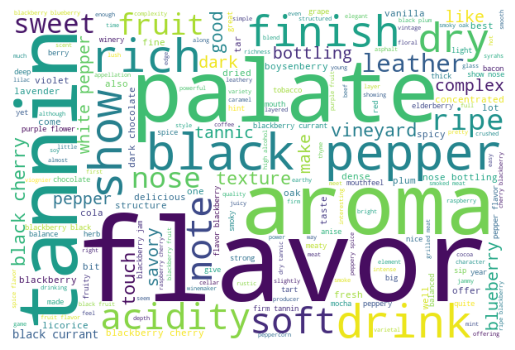

In [54]:
#Initiate wordcloud
descriptions = ' '.join([word for tokens_2 in cal_rev['cleaned_description'] for word in tokens_2])
word_cloud = WordCloud(width=600, height=400, max_words= 200, background_color='white', stopwords=['syrah', 'wine']).generate(descriptions)
plt.imshow(word_cloud)
plt.axis('off')
plt.show()

In [ ]:
#Import image libraries

from PIL import Image

In [58]:
#Initialise shape
web_mask  = np.array(Image.open("C:/Users/ADACHUKWU/OneDrive/Desktop/DataProjects/Data Tips/wine bottle.jpg"))


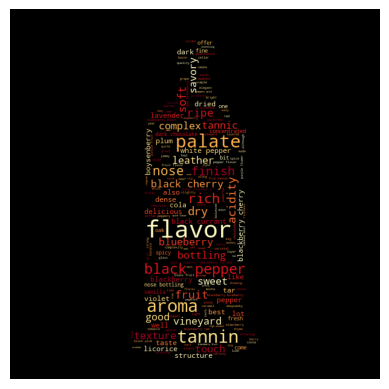

In [65]:
#changing wordcloud shape
word_cloud = WordCloud(width=800, height=1000, max_words= 300, background_color='black', stopwords=['syrah', 'wine', 'make', 'show', 'note', 'drink'], mask=web_mask, colormap='YlOrRd').generate(descriptions)
plt.imshow(word_cloud)
plt.axis('off')
plt.show()

In [ ]:
#To export and use in power Bi
import base64
with open("C:/Users/ADACHUKWU/OneDrive/Desktop/DataProjects/Data Tips/wine bottle.jpg", "rb") as f:
    encoded = base64.b64encode(f.read()).decode()
print(encoded)

/9j/4AAQSkZJRgABAQEBLAEsAAD/4QC2RXhpZgAASUkqAAgAAAAEAA4BAgBaAAAAPgAAAJiCAgAGAAAAmAAAABoBBQABAAAAngAAABsBBQABAAAApgAAAAAAAABHbGFzcyB2b2RrYSBib3R0bGUgd2l0aCBzaWx2ZXIgY2FwLiBWZWN0b3IgaWxsdXN0cmF0aW9uLiBHbGFzcyBib3R0bGUgY29sbGVjdGlvbiwgaXRlbSAxMC5ncnVmZmksAQAAAQAAACwBAAABAAAA/+EF5Wh0dHA6Ly9ucy5hZG9iZS5jb20veGFwLzEuMC8APD94cGFja2V0IGJlZ2luPSLvu78iIGlkPSJXNU0wTXBDZWhpSHpyZVN6TlRjemtjOWQiPz4KPHg6eG1wbWV0YSB4bWxuczp4PSJhZG9iZTpuczptZXRhLyI+Cgk8cmRmOlJERiB4bWxuczpyZGY9Imh0dHA6Ly93d3cudzMub3JnLzE5OTkvMDIvMjItcmRmLXN5bnRheC1ucyMiPgoJCTxyZGY6RGVzY3JpcHRpb24gcmRmOmFib3V0PSIiIHhtbG5zOnBob3Rvc2hvcD0iaHR0cDovL25zLmFkb2JlLmNvbS9waG90b3Nob3AvMS4wLyIgeG1sbnM6SXB0YzR4bXBDb3JlPSJodHRwOi8vaXB0Yy5vcmcvc3RkL0lwdGM0eG1wQ29yZS8xLjAveG1sbnMvIiAgIHhtbG5zOkdldHR5SW1hZ2VzR0lGVD0iaHR0cDovL3htcC5nZXR0eWltYWdlcy5jb20vZ2lmdC8xLjAvIiB4bWxuczpkYz0iaHR0cDovL3B1cmwub3JnL2RjL2VsZW1lbnRzLzEuMS8iIHhtbG5zOnBsdXM9Imh0dHA6Ly9ucy51c2VwbHVzLm9yZy9sZGYveG1wLzEuMC8iICB4bWxuczppcHRjRXh0PSJodHRwOi8vaXB0Yy5vcmcvc3RkL0lwdGM0eG1wRXh0LzIw

## Sentiment Analysis using TextBlob

* Rule Based Sentiment Analysis
* Machine Learning Sentiment Analysis
* Hybrid Models

In [69]:
# Load in Dataset

movie_review = pd.read_csv('../data/IMDB Dataset.csv')
movie_review.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [70]:
movie_review.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [71]:
#truncate the data set using index
movie_review_subset = movie_review.iloc[:10000,:]
movie_review_subset.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
# Create Sentiment Function for polarity score.

def get_sentiment(reviews):
    score = TextBlob(reviews).sentiment.polarity
    return score

In [77]:
movie_review_subset['Polarity Score'] = round(movie_review_subset['review'].apply(get_sentiment),2)

In [79]:
movie_review_subset.head(5)

,review,sentiment,Polarity Score
0,One of the other reviewers has mentioned that ...,positive,0.02
1,A wonderful little production. <br /><br />The...,positive,0.11
2,I thought this was a wonderful way to spend ti...,positive,0.35
3,Basically there's a family where a little boy ...,negative,-0.06
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,0.22
